# 06. V_proxy / HPPC R_int Feature Defense

This ablation defends the feature-engineering choice behind the final Hard-Coulomb pipeline: using `V_proxy = V_t - I * R_int(T)` instead of raw terminal voltage alone.

Raw terminal voltage is not a pure SOC observable. Under dynamic drive-cycle load, it contains at least three coupled terms: equilibrium voltage, instantaneous Ohmic drop, and slower polarization/diffusion overpotential. The Ohmic component is proportional to current and temperature-dependent internal resistance. At cold temperature, `R_int` rises sharply, so the same current pulse produces a larger voltage sag even when internal SOC has not changed enough to justify that voltage change.

The HPPC-derived `R_int(T)` correction is therefore not cosmetic preprocessing. It removes the first-order load-current artifact before the sequence model sees the voltage feature. This does not solve the full low-temperature observability problem, but it prevents the model from learning a false mapping where voltage sag is treated as SOC depletion.


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root containing src/ and data/.')

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FIG_DIR = ROOT / 'outputs' / 'figures' / 'ablation_studies'
FIG_DIR.mkdir(parents=True, exist_ok=True)

from src.preprocessing_v4 import (
    DATA_RAW,
    Q_ACTUAL_PER_TEMP,
    build_ocv_soc_lookup,
    engineer_features_v4,
    read_csv,
)
from src.config import R_INT_PER_TEMP
from src.hppc_rint_extractor import DEFAULT_DATA_ROOT, run_extraction

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'legend.fontsize': 8.5,
    'legend.frameon': False,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.15,
    'grid.linestyle': '-',
    'lines.linewidth': 1.8,
    'lines.markersize': 5,
})

COLORS = {
    '25 C': '#0072B2',
    '-20 C': '#D55E00',
}
print(f'Project root: {ROOT}')
print(f'Figure output: {FIG_DIR}')


Project root: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC
Figure output: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies


## HPPC reproducibility check

The correction is only defensible if the resistance table is reproducible from raw HPPC pulse data. The cell below reruns the repository extractor and checks that the script-calculated `R_int` values match the locked config table.


In [2]:
hppc_rows, hppc_summaries = run_extraction(DEFAULT_DATA_ROOT, tolerance_mohm=0.01)
rint_df = pd.DataFrame(hppc_rows).rename(columns={
    'temp': 'Temperature',
    'file': 'HPPC file',
    'pulses': 'Pulses',
    'script_mohm': 'Script R_int (mOhm)',
    'paper_mohm': 'Config R_int (mOhm)',
    'delta_mohm': 'Delta (mOhm)',
    'status': 'Status',
})
display(rint_df)
assert (rint_df['Status'] == 'PASS').all(), 'HPPC R_int reproduction failed.'


,Temperature,HPPC file,Pulses,Script R_int (mOhm),Config R_int (mOhm),Delta (mOhm),Status
0,40°C,555_HPPC.csv,55,16.506451,16.51,-0.003549,PASS
1,25°C,549_HPPC.csv,60,19.859679,19.86,-0.000321,PASS
2,10°C,575_HPPC.csv,55,28.748757,28.75,-0.001243,PASS
3,0°C,585_HPPC.csv,50,40.082381,40.08,0.002381,PASS
4,-10°C,593_HPPC.csv,50,62.185880,62.19,-0.004120,PASS
5,-20°C,607_HPPC.csv,45,109.829799,109.83,-0.000201,PASS


## Raw voltage versus V_proxy

This visualization uses representative UDDS profiles at `25 C` and `-20 C`. The left panel shows raw terminal voltage against Coulomb-counted SOC. The right panel applies the HPPC Ohmic correction. At `-20 C`, the correction is larger because `R_int` is larger, which is exactly the electrochemical failure mode that makes raw voltage misleading under load.


In [3]:
PROFILE_SPECS = [
    {'temp_key': '25degC', 'label': '25 C', 'file': '551_UDDS.csv', 'sample_stride': 25},
    {'temp_key': 'n20degC', 'label': '-20 C', 'file': '610_UDDS.csv', 'sample_stride': 15},
]

def load_engineered_profile(spec):
    path = Path(DATA_RAW) / spec['temp_key'] / spec['file']
    if not path.exists():
        raise FileNotFoundError(path)
    raw = read_csv(str(path))
    ocv_lookup, _ = build_ocv_soc_lookup(spec['temp_key'])
    engineered, soc_initial = engineer_features_v4(
        raw,
        q_actual=Q_ACTUAL_PER_TEMP[spec['temp_key']],
        r_int=R_INT_PER_TEMP[spec['temp_key']],
        ocv_lookup=ocv_lookup,
    )
    keep = engineered[['time_sec', 'SOC_cc', 'Voltage', 'Current', 'V_proxy']].dropna().copy()
    keep = keep.iloc[::spec['sample_stride']].reset_index(drop=True)
    keep['SOC_pct'] = keep['SOC_cc'] * 100.0
    keep['Temperature'] = spec['label']
    keep['R_int_mOhm'] = R_INT_PER_TEMP[spec['temp_key']] * 1000.0
    keep['SOC_initial_pct'] = soc_initial * 100.0
    keep['Source file'] = spec['file']
    return keep

profiles = pd.concat([load_engineered_profile(spec) for spec in PROFILE_SPECS], ignore_index=True)
summary = (
    profiles.groupby(['Temperature', 'Source file'], as_index=False)
    .agg(
        Samples=('Voltage', 'size'),
        R_int_mOhm=('R_int_mOhm', 'first'),
        SOC_min_pct=('SOC_pct', 'min'),
        SOC_max_pct=('SOC_pct', 'max'),
        V_raw_min=('Voltage', 'min'),
        V_raw_max=('Voltage', 'max'),
        V_proxy_min=('V_proxy', 'min'),
        V_proxy_max=('V_proxy', 'max'),
    )
)
display(summary.round(3))


,Temperature,Source file,Samples,R_int_mOhm,SOC_min_pct,SOC_max_pct,V_raw_min,V_raw_max,V_proxy_min,V_proxy_max
0,-20 C,610_UDDS.csv,5461,109.83,31.741,99.877,2.799,4.201,3.153,4.188
1,25 C,551_UDDS.csv,6386,19.86,6.627,99.985,2.940,4.200,3.043,4.189


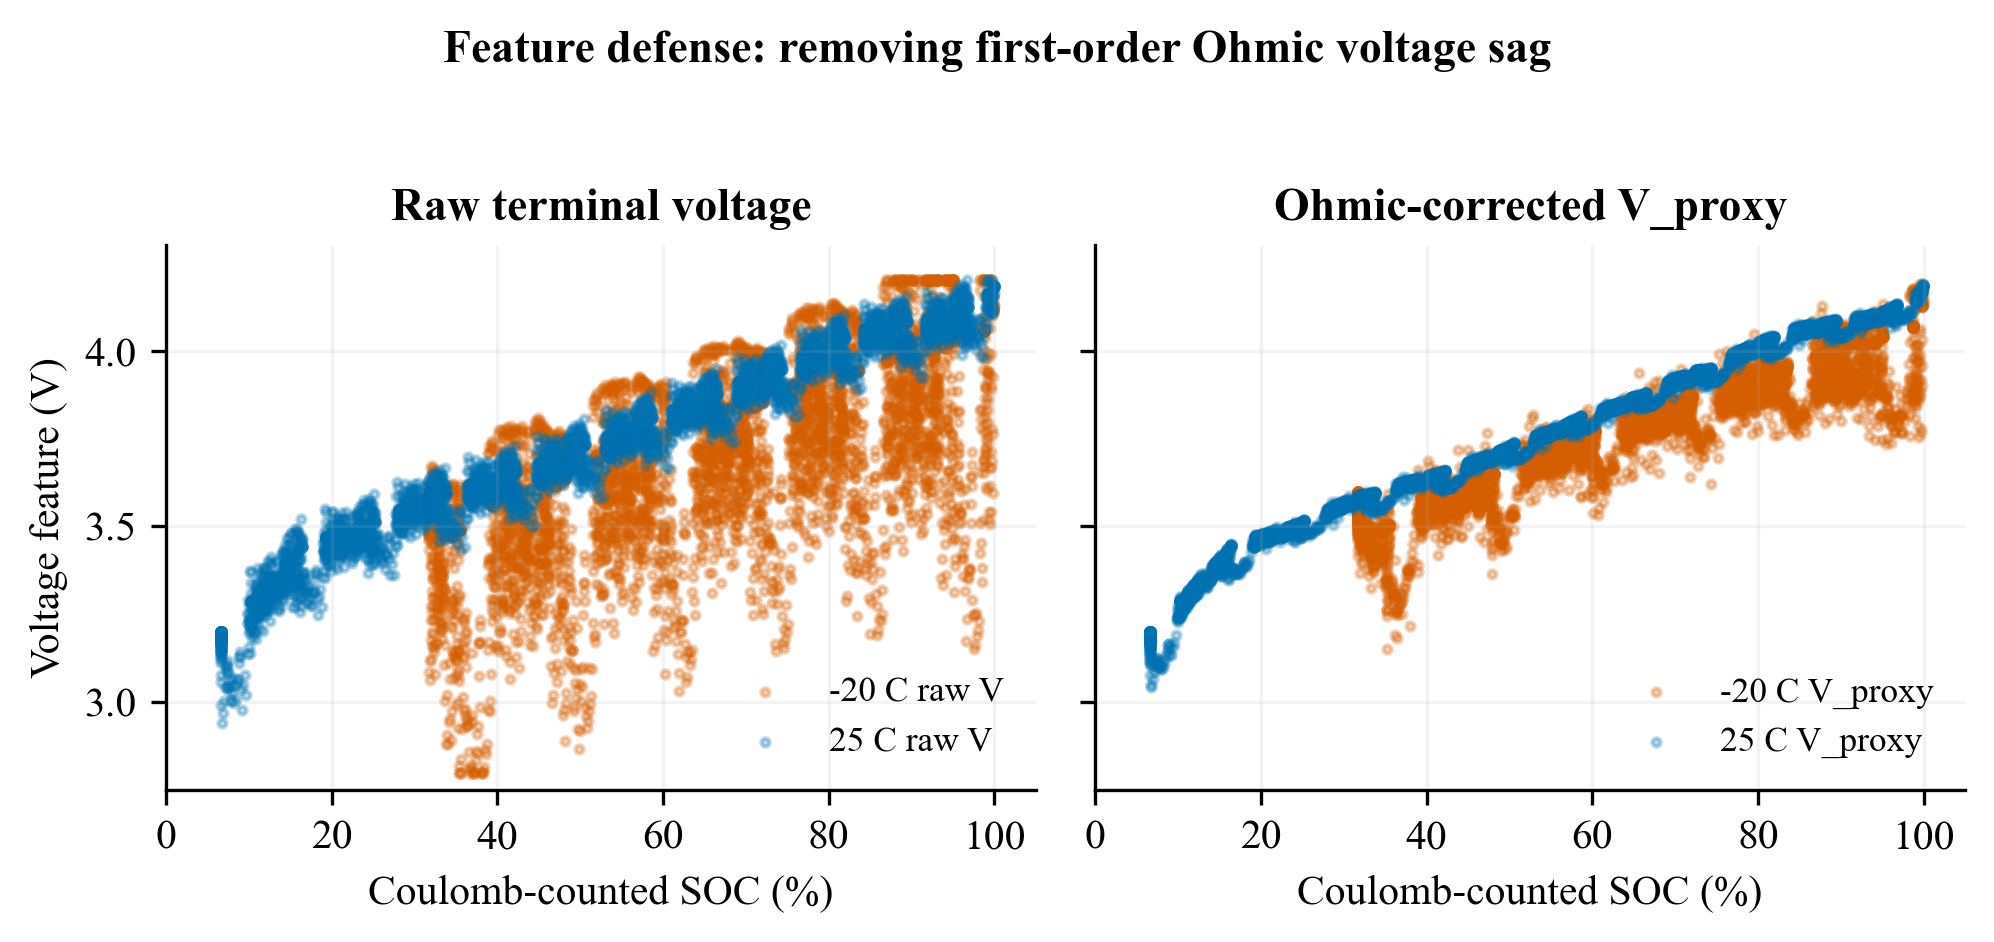

Saved: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies\fig_06_vproxy_feature_defense.pdf
Saved: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies\fig_06_vproxy_feature_defense.png


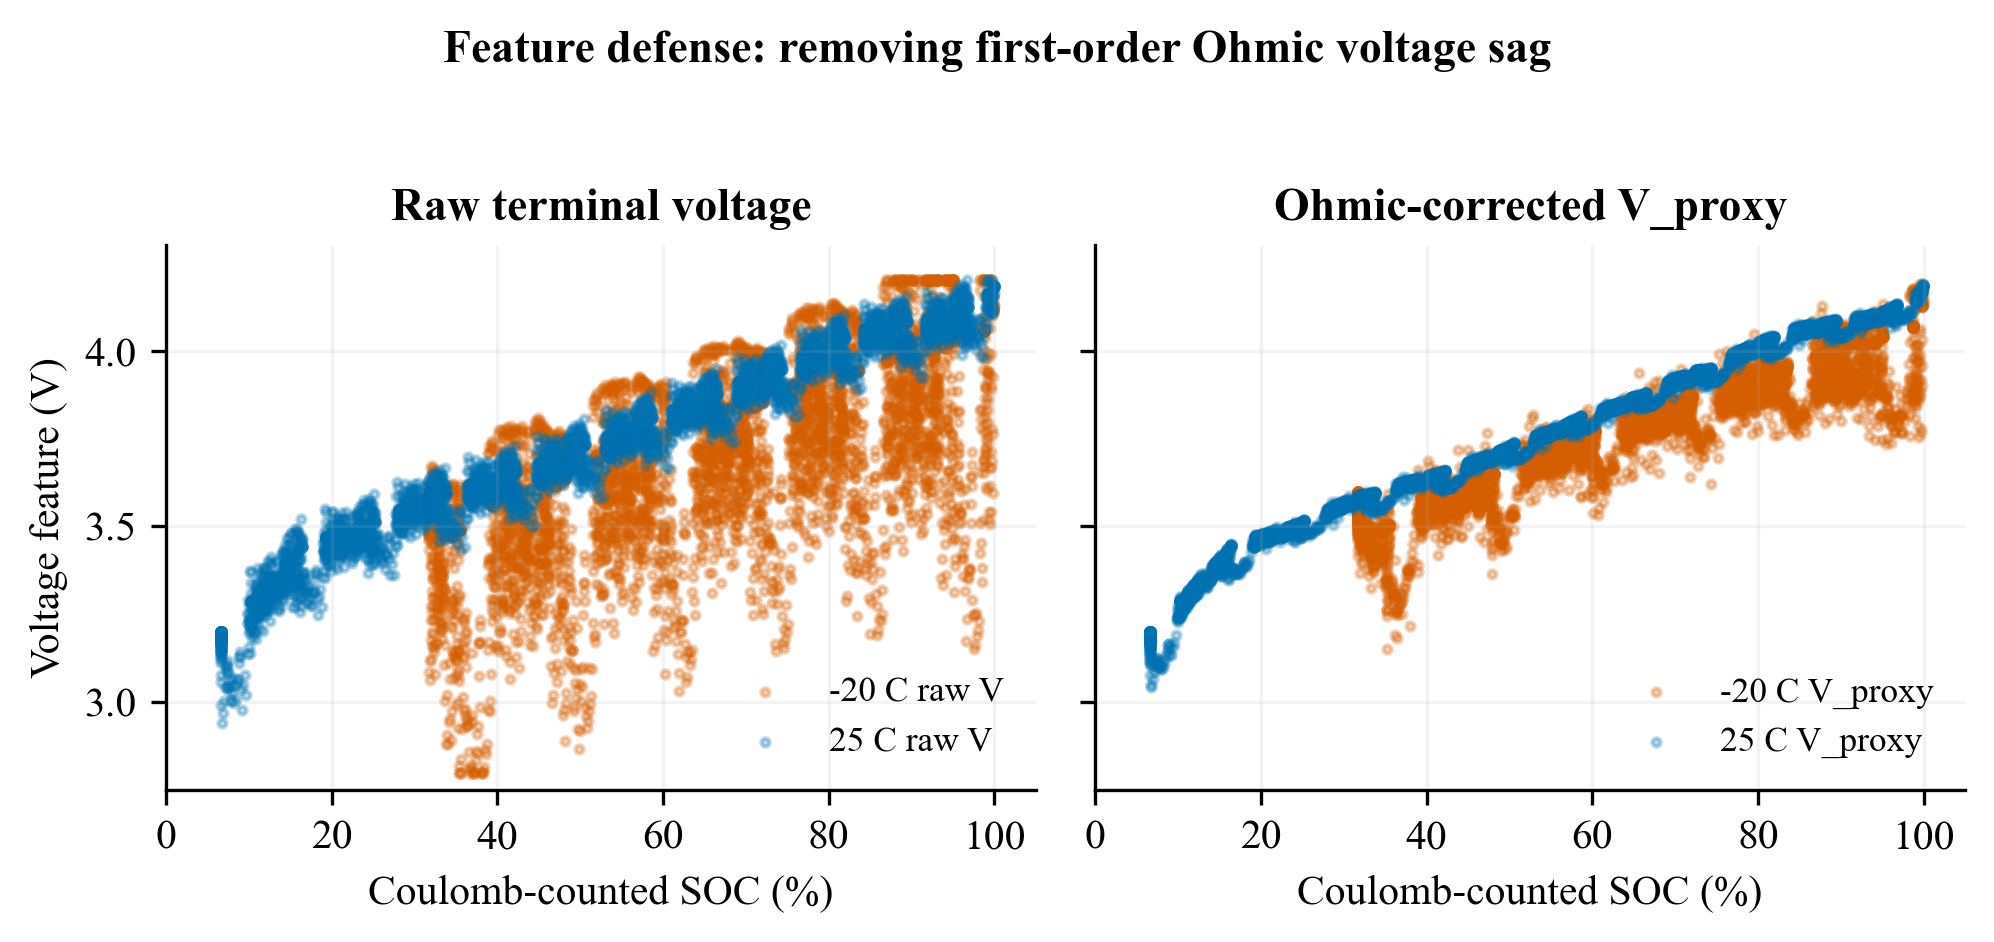

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(6.75, 3.0), sharex=True, sharey=True)

for label, group in profiles.groupby('Temperature'):
    color = COLORS[label]
    order = group.sort_values('SOC_pct')
    axes[0].scatter(
        order['SOC_pct'], order['Voltage'], s=4, alpha=0.28, color=color,
        label=f'{label} raw V', rasterized=True
    )
    axes[1].scatter(
        order['SOC_pct'], order['V_proxy'], s=4, alpha=0.28, color=color,
        label=f'{label} V_proxy', rasterized=True
    )

axes[0].set_title('Raw terminal voltage')
axes[1].set_title('Ohmic-corrected V_proxy')
for ax in axes:
    ax.set_xlabel('Coulomb-counted SOC (%)')
    ax.set_xlim(0, 105)
    ax.set_ylim(2.75, 4.30)
    ax.legend(loc='lower right')
axes[0].set_ylabel('Voltage feature (V)')

fig.suptitle('Feature defense: removing first-order Ohmic voltage sag', y=1.03, fontsize=11, fontweight='bold')
fig.tight_layout()
pdf_path = FIG_DIR / 'fig_06_vproxy_feature_defense.pdf'
png_path = FIG_DIR / 'fig_06_vproxy_feature_defense.png'
fig.savefig(pdf_path)
fig.savefig(png_path, dpi=300)
display(fig)
print(f'Saved: {pdf_path}')
print(f'Saved: {png_path}')


## Interpretation

A perfect voltage feature would collapse dynamic-drive scatter into a tighter SOC relation. `V_proxy` cannot remove slow polarization or solid-diffusion hysteresis, especially at `-20 C`, but it removes the instantaneous `I * R_int` term with a reproducible HPPC estimate. That is the feature-defense claim: `V_proxy` is a necessary first-order physical correction, not a sufficient solution to cold-temperature observability.
